In [2]:
import pandas as pd 
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

In [5]:
df=pd.read_csv('AirPassengers.csv', parse_dates=['Month'],index_col='Month')

In [6]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


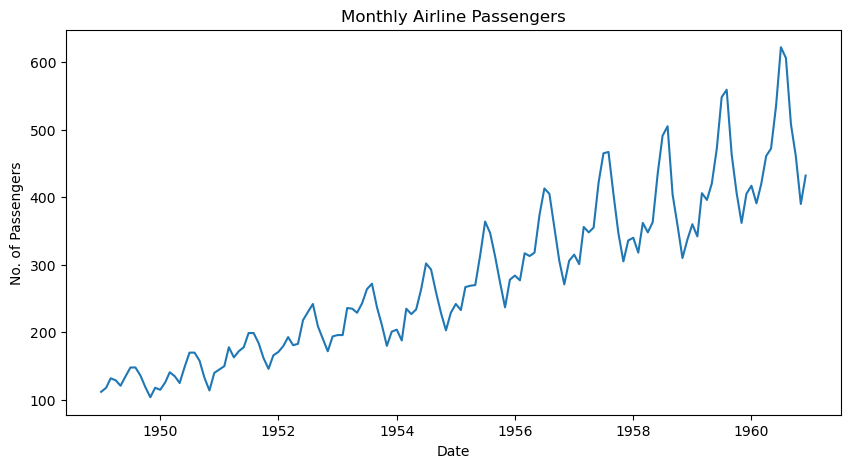

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df)
plt.title('Monthly Airline Passengers')
plt.xlabel('Date')
plt.ylabel('No. of Passengers')
plt.show()

In [16]:
# Check Stationary

In [17]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [19]:
result=adfuller(df['#Passengers'])
print('ADF Statistics:',result[0])
print('p-value:',result[1])

ADF Statistics: 0.8153688792060482
p-value: 0.991880243437641


In [20]:
df_diff=df.diff().dropna()


In [21]:
result1=adfuller(df_diff['#Passengers'])
print('ADF Stats:',result1[0])
print('p-value:',result1[1])

ADF Stats: -2.8292668241699994
p-value: 0.0542132902838255


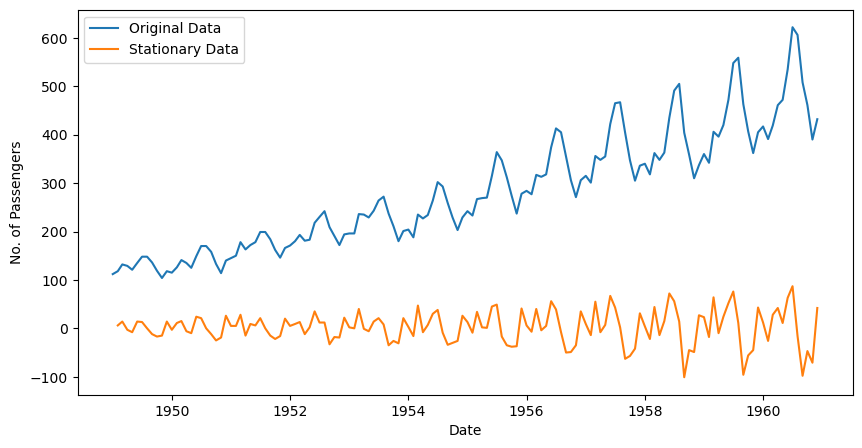

In [22]:
plt.figure(figsize=(10,5))
plt.plot(df,label='Original Data')
plt.plot(df_diff,label='Stationary Data')

plt.xlabel('Date')
plt.ylabel('No. of Passengers')

plt.legend()
plt.show()

In [ ]:
# plot acf and pacf for p and q

In [41]:
lags=min(40,len(df_diff))
print(lags)

40


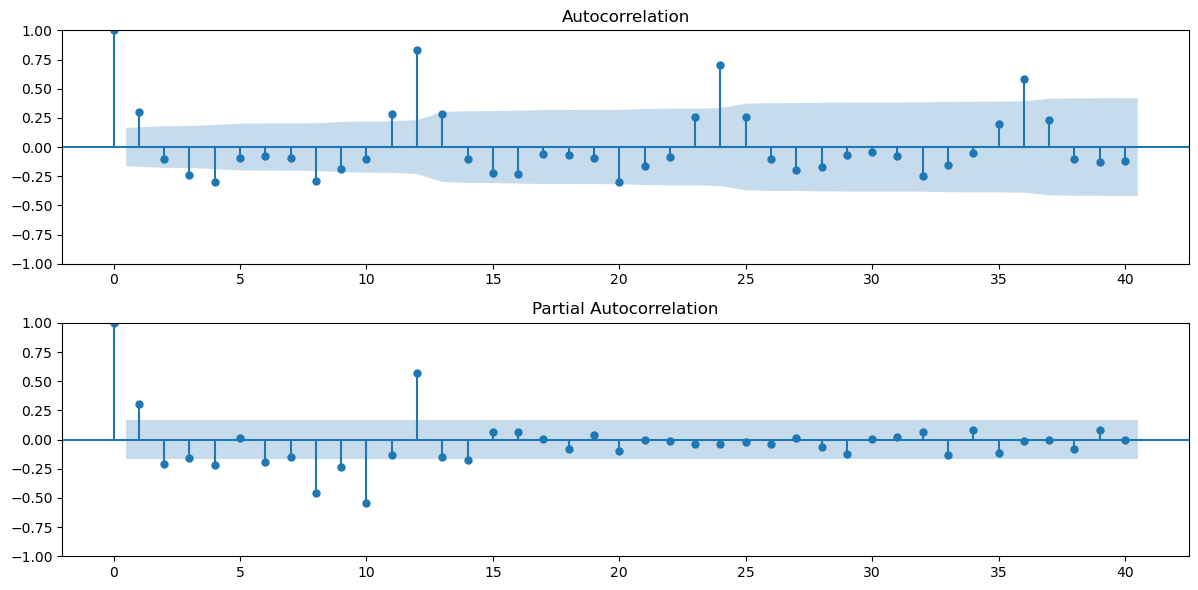

In [40]:
fig,ax=plt.subplots(2,1,figsize=(12,6))
plot_acf(df_diff,lags=lags,ax=ax[0])
plot_pacf(df_diff,lags=lags,ax=ax[1])

plt.tight_layout()
plt.show()

In [25]:
# fit the ARIMA model with params (1,0,1)  

In [26]:
model=ARIMA(df_diff,order=(1,0,1))
mdl_fit=model.fit()

mdl_fit.summary()
            

  self._init_dates(dates, freq)
  self._init_dates(dates, freq)
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            #Passengers   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -694.061
Date:                Fri, 20 Jun 2025   AIC                           1396.122
Time:                        14:32:28   BIC                           1407.973
Sample:                    02-01-1949   HQIC                          1400.937
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4507      3.441      0.712      0.476      -4.293       9.195
ar.L1         -0.4767      0.128     -3.735      0.000      -0.727      -0.227
ma.L1          0.8645      0.080     10.743      0.000       0.707       1.022
sigma2       958.5228    107.063      8.953      0.000     748.683    1168.363
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                 2.17
Prob(Q):                              0.64   Prob(JB):                         0.34
Heteroskedasticity (H):               7.01   Skew:                            -0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.43
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
# make predictions

In [32]:
start=len(df_diff)
end=start+20
predictions=mdl_fit.predict(start=start,end=end,dynamic=False)

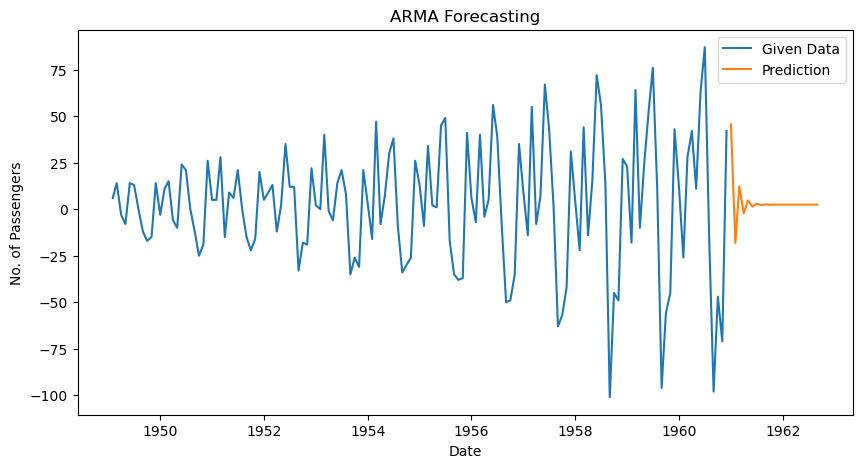

In [33]:
plt.figure(figsize=(10,5))
plt.plot(df_diff,label='Given Data')
plt.plot(predictions,label='Prediction')

plt.title('ARMA Forecasting')

plt.xlabel('Date')
plt.ylabel('No. of Passengers')

plt.legend()
plt.show()